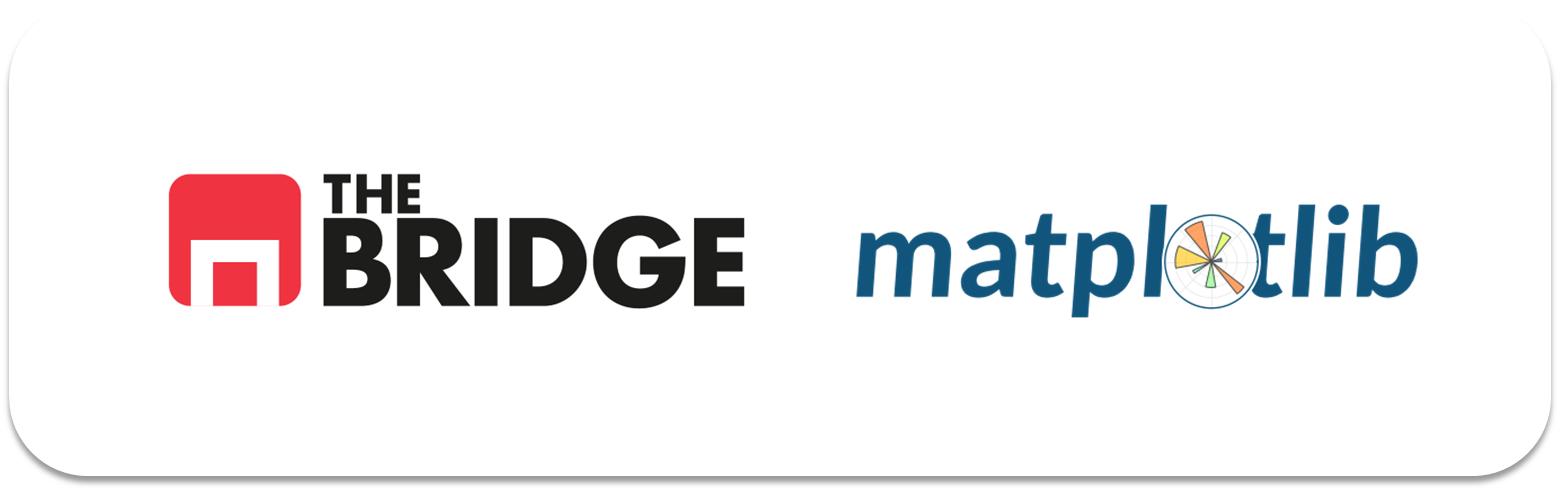

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [6]:
df = pd.read_csv("data/california_cities.csv", index_col= 0)

In [7]:
df.head(10)


,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
5,AlisoViejo,33.575000,-117.725556,127.0,417.0,47823,7.472,7.472,0.000,19.352,19.352,0.000,0.00
6,Alturas,41.487222,-120.542500,1332.0,4370.0,2827,2.449,2.435,0.014,6.342,6.306,0.036,0.57
7,AmadorCity,38.419444,-120.824167,280.0,919.0,185,0.314,0.314,0.000,0.813,0.813,0.000,0.00
8,AmericanCanyon,38.168056,-122.252500,14.0,46.0,19454,4.845,4.837,0.008,12.548,12.527,0.021,0.17
9,Anaheim,33.836111,-117.889722,48.0,157.0,336000,50.811,49.835,0.976,131.600,129.073,2.527,1.92


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                482 non-null    str    
 1   latd                482 non-null    float64
 2   longd               482 non-null    float64
 3   elevation_m         434 non-null    float64
 4   elevation_ft        470 non-null    float64
 5   population_total    482 non-null    int64  
 6   area_total_sq_mi    480 non-null    float64
 7   area_land_sq_mi     482 non-null    float64
 8   area_water_sq_mi    481 non-null    float64
 9   area_total_km2      477 non-null    float64
 10  area_land_km2       478 non-null    float64
 11  area_water_km2      478 non-null    float64
 12  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(1), str(1)
memory usage: 49.1 KB


In [ ]:
df.isna().sum().sort_values(ascending=False)

elevation_m           48
elevation_ft          12
area_water_percent     5
area_total_km2         5
area_water_km2         4
area_land_km2          4
area_total_sq_mi       2
area_water_sq_mi       1
city                   0
latd                   0
longd                  0
area_land_sq_mi        0
population_total       0
dtype: int64

In [22]:
df["elevation_m_from_ft"] = df.elevation_ft * 0.3048

In [23]:
df["elevation_m"] = df["elevation_m"].fillna(df["elevation_m_from_ft"])

In [24]:
df.isna().sum().sort_values(ascending=False)

elevation_ft           8
elevation_m            8
elevation_m_from_ft    8
area_total_km2         5
area_water_percent     5
area_water_km2         4
area_land_km2          4
area_total_sq_mi       2
area_water_sq_mi       1
latd                   0
population_total       0
longd                  0
city                   0
area_land_sq_mi        0
dtype: int64

In [25]:
mascara = df["elevation_ft"].isnull() & df["elevation_m"].notnull()
df.loc[mascara, "elevation_ft"] = df.loc[mascara, "elevation_m"] / 0.3048

In [26]:
df.isna().sum().sort_values(ascending=False)

elevation_ft           8
elevation_m            8
elevation_m_from_ft    8
area_total_km2         5
area_water_percent     5
area_water_km2         4
area_land_km2          4
area_total_sq_mi       2
area_water_sq_mi       1
latd                   0
population_total       0
longd                  0
city                   0
area_land_sq_mi        0
dtype: int64

In [27]:
df = df.dropna()

In [28]:
df.isna().sum().sort_values(ascending=False)

city                   0
latd                   0
longd                  0
elevation_m            0
elevation_ft           0
population_total       0
area_total_sq_mi       0
area_land_sq_mi        0
area_water_sq_mi       0
area_total_km2         0
area_land_km2          0
area_water_km2         0
area_water_percent     0
elevation_m_from_ft    0
dtype: int64

Las variables `elevation_m` y `elevation_ft` representan la misma información en distintas unidades, por lo que se imputaron los valores faltantes mediante conversión entre metros y pies. 

Posteriormente, se eliminaron únicamente las filas que continuaban con valores nulos.

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

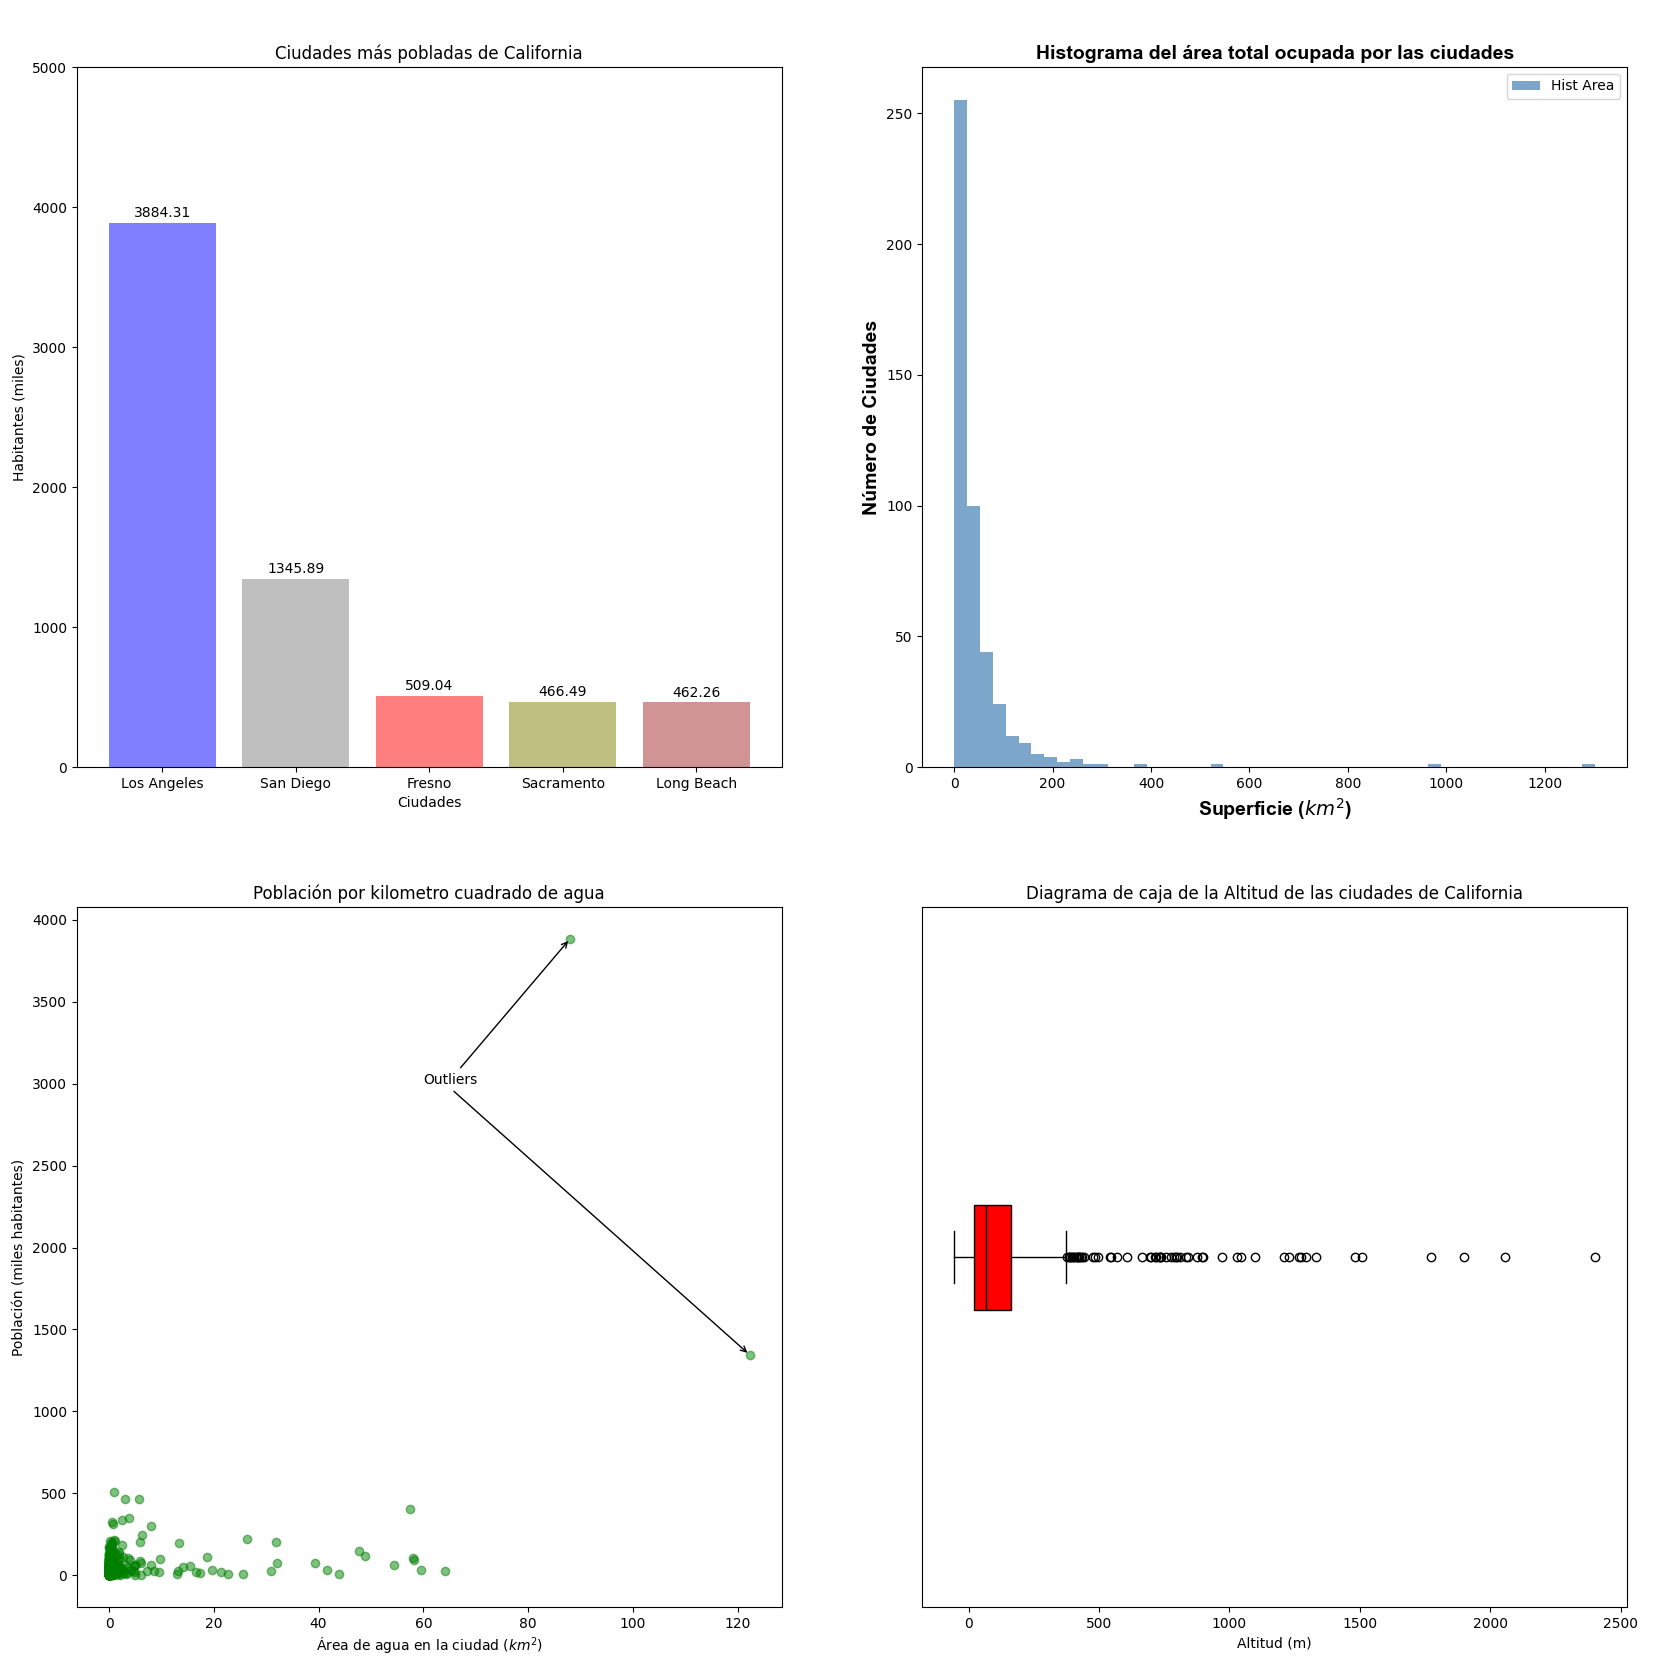

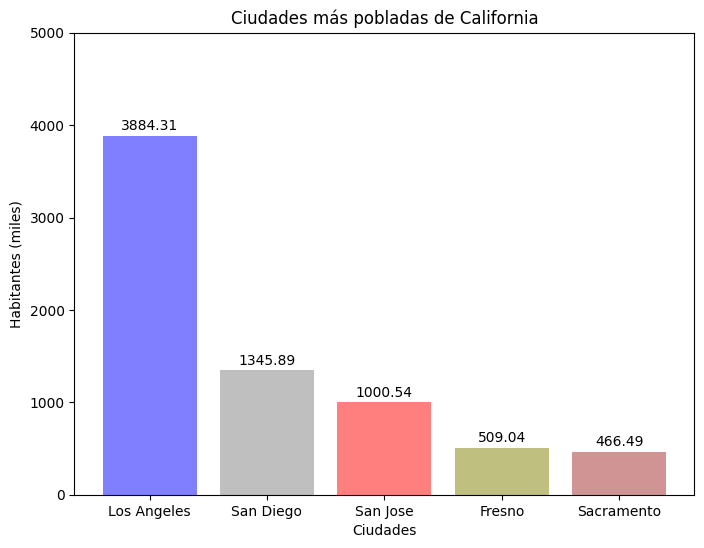

In [36]:
def separa_nombre(nombre):
    nuevo = nombre[0]
    for letra in nombre[1:]:
        if letra == letra.upper():
            nuevo += " "
        nuevo += letra
    return nuevo

df_ciudades_mas_pobladas = df[["city","population_total"]].nlargest(5, columns="population_total").copy()
df_ciudades_mas_pobladas = df_ciudades_mas_pobladas.set_index("city")
df_ciudades_mas_pobladas

ciudades = [separa_nombre(ciudad) for ciudad in df_ciudades_mas_pobladas.index]
colores = ["blue","gray","red","olive","brown"]

plt.figure(figsize=(8,6))

container = plt.bar(x=ciudades,
        height= df_ciudades_mas_pobladas["population_total"]/1000,
        color=colores,
        alpha=0.5)

plt.ylim(0,5000)
plt.ylabel("Habitantes (miles)")
plt.xlabel("Ciudades")
plt.title("Ciudades más pobladas de California")

plt.bar_label(container,
              fmt="{:.2f}",
              padding=2)

plt.show()

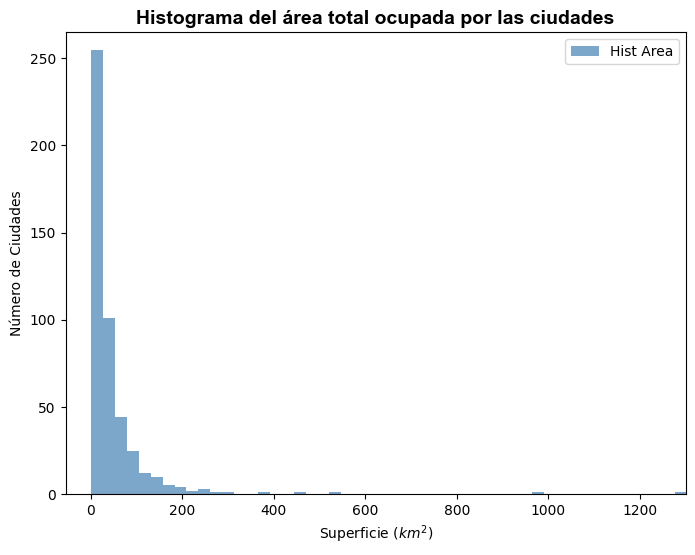

In [47]:
# Histograma del área total ocupada por las ciudades

plt.figure(figsize=(8,6))

plt.hist(
    df["area_total_km2"],
    bins=50,
    color="steelblue",
    alpha=0.7,
    label="Hist Area"
)

plt.title(
    "Histograma del área total ocupada por las ciudades",
    fontname="Arial",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Superficie ($km^2$)")
plt.ylabel("Número de Ciudades")

plt.xlim(-55,1300)
plt.ylim(0,265)

plt.legend()

plt.show()

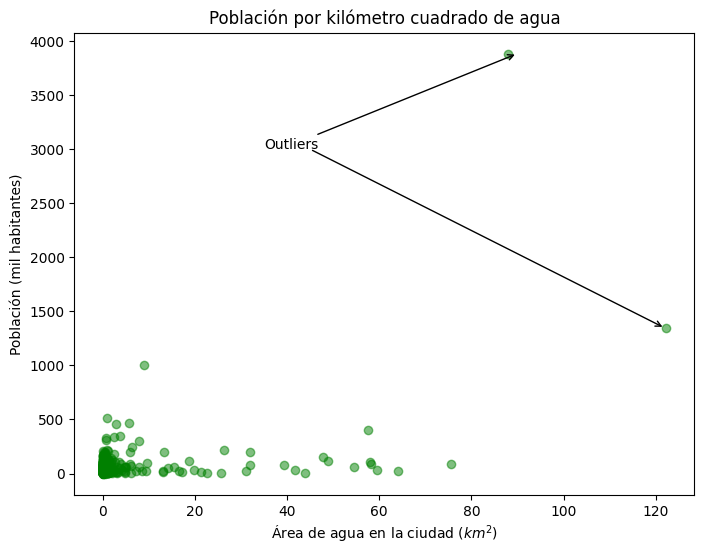

In [56]:
# El scatter de área de agua de un ciudad con su poblacion.

plt.figure(figsize=(8,6))

plt.scatter(
    df["area_water_km2"],
    df["population_total"] / 1000,
    color="green",
    alpha=0.5
)

plt.title("Población por kilómetro cuadrado de agua")
plt.xlabel("Área de agua en la ciudad ($km^2$)")
plt.ylabel("Población (mil habitantes)")

plt.annotate(
    "Outliers",
    xy=(90, 3884),
    xytext=(35, 3000),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "",
    xy=(122, 1345),
    xytext=(45, 3000),
    arrowprops=dict(arrowstyle="->")
)

plt.show()

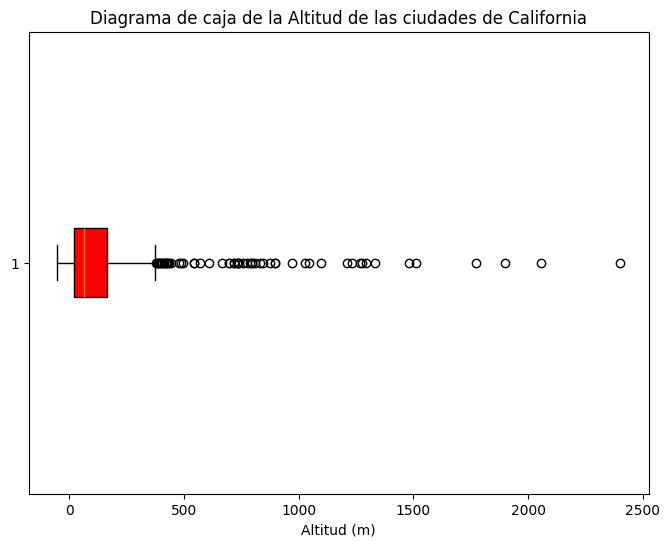

In [57]:
plt.figure(figsize=(8,6))

plt.boxplot(
    df["elevation_m"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="red")
)

plt.title("Diagrama de caja de la Altitud de las ciudades de California")

plt.xlabel("Altitud (m)")

plt.show()

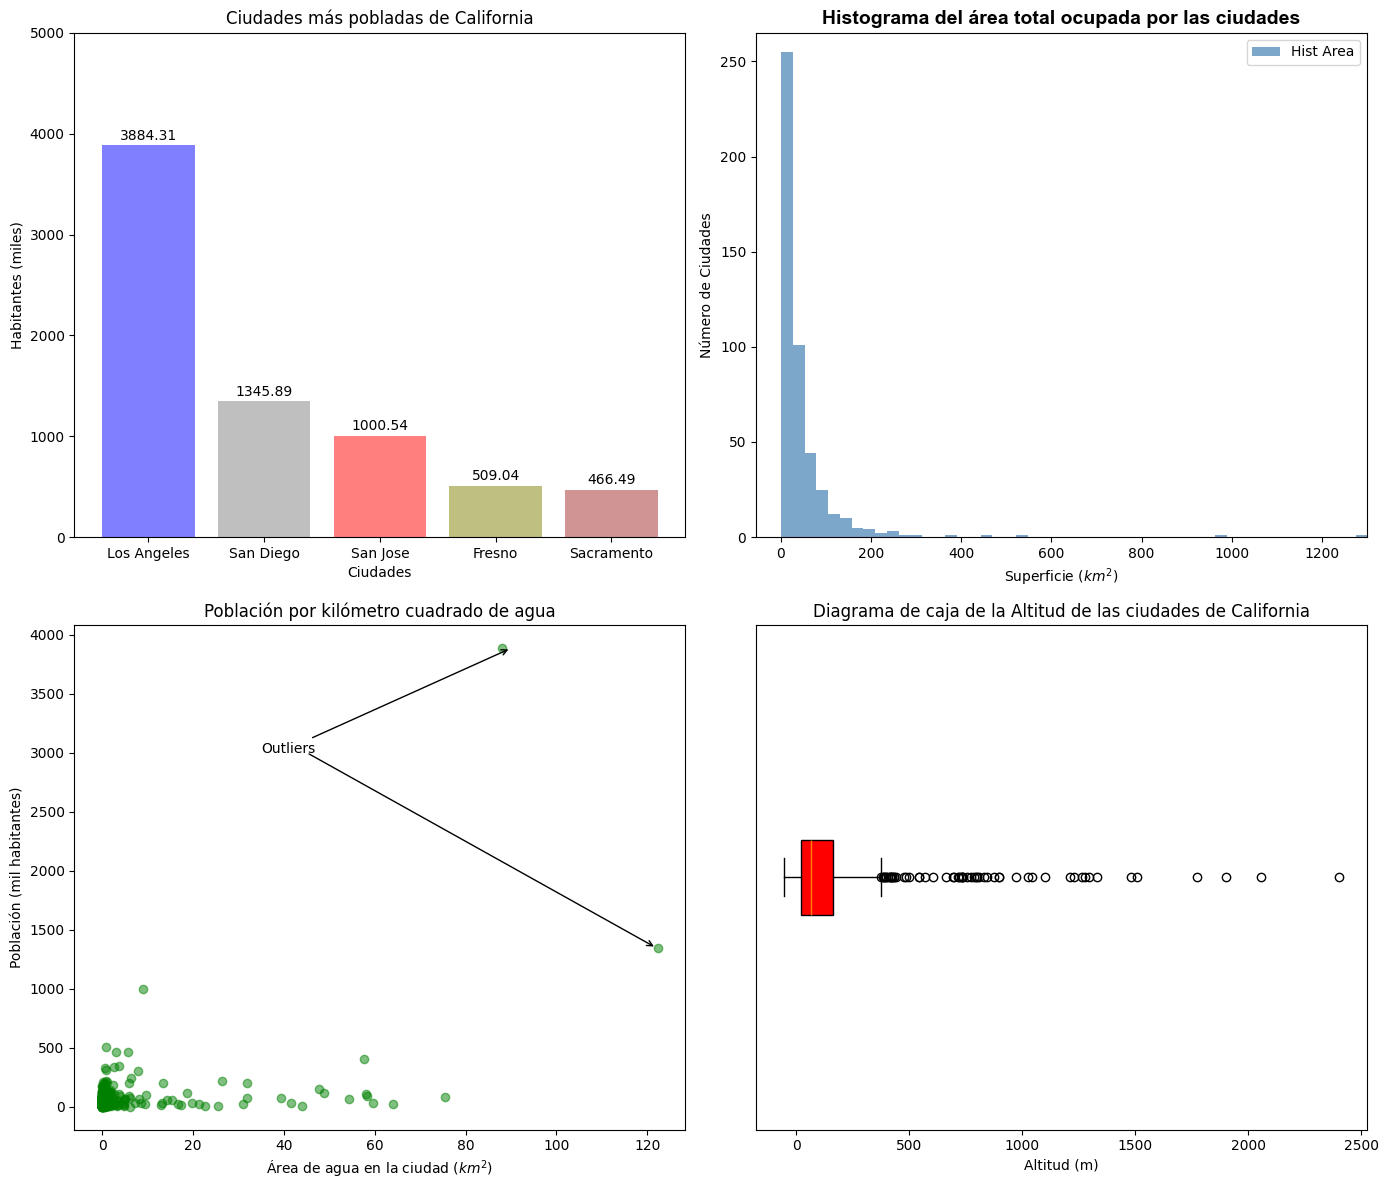

In [65]:
fig = plt.figure(figsize=(14, 12))

# Figura 1
plt.subplot(2, 2, 1)

def separa_nombre(nombre):
    nuevo = nombre[0]
    for letra in nombre[1:]:
        if letra == letra.upper():
            nuevo += " "
        nuevo += letra
    return nuevo

df_ciudades_mas_pobladas = df[["city","population_total"]].nlargest(5, columns="population_total").copy()
df_ciudades_mas_pobladas = df_ciudades_mas_pobladas.set_index("city")

ciudades = [separa_nombre(ciudad) for ciudad in df_ciudades_mas_pobladas.index]
colores = ["blue","gray","red","olive","brown"]

container = plt.bar(
    x=ciudades,
    height=df_ciudades_mas_pobladas["population_total"] / 1000,
    color=colores,
    alpha=0.5
)

plt.ylim(0,5000)
plt.ylabel("Habitantes (miles)")
plt.xlabel("Ciudades")
plt.title("Ciudades más pobladas de California")

plt.bar_label(container, fmt="{:.2f}", padding=2)


# Figura 2
plt.subplot(2, 2, 2)

plt.hist(
    df["area_total_km2"],
    bins=50,
    color="steelblue",
    alpha=0.7,
    label="Hist Area"
)

plt.title(
    "Histograma del área total ocupada por las ciudades",
    fontname="Arial",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Superficie ($km^2$)")
plt.ylabel("Número de Ciudades")
plt.xlim(-55,1300)
plt.ylim(0,265)
plt.legend()


# Figura 3
plt.subplot(2, 2, 3)

plt.scatter(
    df["area_water_km2"],
    df["population_total"] / 1000,
    color="green",
    alpha=0.5
)

plt.title("Población por kilómetro cuadrado de agua")
plt.xlabel("Área de agua en la ciudad ($km^2$)")
plt.ylabel("Población (mil habitantes)")

plt.annotate(
    "Outliers",
    xy=(90, 3884),
    xytext=(35, 3000),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "",
    xy=(122, 1345),
    xytext=(45, 3000),
    arrowprops=dict(arrowstyle="->")
)


# Figura 4
plt.subplot(2, 2, 4)

plt.boxplot(
    df["elevation_m"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="red")
)

plt.xlabel("Altitud (m)")
plt.title("Diagrama de caja de la Altitud de las ciudades de California")
plt.yticks([])

plt.tight_layout()
plt.show()


#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [66]:
fig.savefig("practica_obligatoria.png")

In [67]:
import matplotlib.font_manager as fm

print(fm.findfont("DejaVu Sans"))

C:\Users\angel\Documents\GitHub\DS_Online_Angelica_Sanchez\.venv\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\DejaVuSans.ttf
